#**PART B: STRUCTURAL DISCOVERY AND ADVANCED EXPLANATION**

Necessary Imports

In [88]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Model
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.callbacks import EarlyStopping


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rank_gauss = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pyarrow as pa
import pyarrow.parquet as pq

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
train=pd.read_parquet('/content/drive/MyDrive/veritas_cassandra/train_purified_A.parquet')
test=pd.read_parquet('/content/drive/MyDrive/veritas_cassandra/test_purified_A.parquet')


The columns present after stochastic noise elimination in Part-A.

In [5]:
calc_cols = [c for c in train.columns if 'calc' in c]
print(f"Data Loaded. Number of '_calc' features found: {len(calc_cols)}")

print(f"\n--- Purified Dataset Overview ---")
print(f"Train Shape: {train.shape}")

groups = {'ind': [], 'reg': [], 'car': [], 'other': []}
for col in train.columns:
    if 'ps_ind' in col:
        groups['ind'].append(col)
    elif 'ps_reg' in col:
        groups['reg'].append(col)
    elif 'ps_car' in col:
        groups['car'].append(col)
    else:
        groups['other'].append(col)

print("\nFeature Distribution by Domain:")
for g, cols in groups.items():
    print(f"{g.upper()}: {len(cols)}")

features_to_show = [c for c in train.columns if c not in ['id', 'target']]

print(f"\nClean Input Features ({len(features_to_show)} total):")
for col in features_to_show:
    print(col)

Data Loaded. Number of '_calc' features found: 0

--- Purified Dataset Overview ---
Train Shape: (148462, 39)

Feature Distribution by Domain:
IND: 18
REG: 3
CAR: 16
OTHER: 2

Clean Input Features (37 total):
ps_ind_01
ps_ind_02_cat
ps_ind_03
ps_ind_04_cat
ps_ind_05_cat
ps_ind_06_bin
ps_ind_07_bin
ps_ind_08_bin
ps_ind_09_bin
ps_ind_10_bin
ps_ind_11_bin
ps_ind_12_bin
ps_ind_13_bin
ps_ind_14
ps_ind_15
ps_ind_16_bin
ps_ind_17_bin
ps_ind_18_bin
ps_reg_01
ps_reg_02
ps_reg_03
ps_car_01_cat
ps_car_02_cat
ps_car_03_cat
ps_car_04_cat
ps_car_05_cat
ps_car_06_cat
ps_car_07_cat
ps_car_08_cat
ps_car_09_cat
ps_car_10_cat
ps_car_11_cat
ps_car_11
ps_car_12
ps_car_13
ps_car_14
ps_car_15


In [8]:
train_cols = set(train.columns)
test_cols = set(test.columns)
diff_cols = list(train_cols - test_cols)
print(f"Column(s) present in 'train' but not in 'test': {diff_cols}")

Column(s) present in 'train' but not in 'test': ['target']


In [9]:
train_target = train['target'].values

train_ids = train['id'].values
test_ids = test['id'].values

X_train = train.drop(columns=['id', 'target'], errors='ignore')
X_test = test.drop(columns=['id'], errors='ignore')


Metadata classification based on categories (binary, categorical, and continuous) and semantic suffixes.

In [10]:
meta= []

for col in X_train.columns:
    # 1. Role
    role = 'target' if col == 'target' else ('id' if col == 'id' else 'input')

    # 2. Group
    group = col.split('_')[1] if col.startswith('ps_') else 'other'

    # 3. Unique Counts
    n_unique = X_train[col].nunique()

    # 4. Feature Type with Semantic Overrides
    if col == 'target' or 'bin' in col:
        ftype = 'binary'
    elif 'cat' in col:
        ftype = 'nominal'
    # Registration and specific Car features are mathematically continuous
    elif 'reg' in col or col == 'ps_car_15':
        ftype = 'continuous'
    # Thresholding for remaining features
    elif n_unique < 20:
        ftype = 'ordinal'
    else:
        ftype = 'continuous'


    meta.append({
        'feature': col,
        'role': role,
        'group': group,
        'type': ftype,
        'n_unique': n_unique,
        # Missing values presentas -1
        'missing': (X_train[col] == -1).sum() + X_train[col].isnull().sum()
    })

meta_df = pd.DataFrame(meta).set_index('feature')

meta_df

,role,group,type,n_unique,missing
feature,,,,,
ps_ind_01,input,ind,ordinal,8,0
ps_ind_02_cat,input,ind,nominal,5,54
ps_ind_03,input,ind,ordinal,12,0
ps_ind_04_cat,input,ind,nominal,3,20
ps_ind_05_cat,input,ind,nominal,8,1452
ps_ind_06_bin,input,ind,binary,2,0
ps_ind_07_bin,input,ind,binary,2,0
ps_ind_08_bin,input,ind,binary,2,0
ps_ind_09_bin,input,ind,binary,2,0


Creating binary flags to capture missing-value signals and then imputing missing entries using median (numeric) and most frequent (categorical) values for model compatibility.

In [12]:

cols_with_missing = [col for col in X_train.columns if (X_train[col] == -1).any()]

print(f"Creating binary flags for {len(cols_with_missing)} columns...")

for col in cols_with_missing:
    X_train[f"{col}_nan"] = (X_train[col] == -1).astype(np.int8)
    X_test[f"{col}_nan"] = (X_test[col] == -1).astype(np.int8)

cont_ord_cols = meta_df[meta_df['type'].isin(['continuous', 'ordinal'])].index.tolist()
nom_cols = meta_df[meta_df['type'] == 'nominal'].index.tolist()

#  Impute Continuous & Ordinal (Median)

imputer_num = SimpleImputer(strategy='median', missing_values=-1)

X_train[cont_ord_cols] = imputer_num.fit_transform(X_train[cont_ord_cols])
X_test[cont_ord_cols] = imputer_num.transform(X_test[cont_ord_cols])

#  Impute Nominal/Categorical (Most Frequent)

imputer_cat = SimpleImputer(strategy='most_frequent', missing_values=-1)

X_train[nom_cols] = imputer_cat.fit_transform(X_train[nom_cols])
X_test[nom_cols] = imputer_cat.transform(X_test[nom_cols])

print("Imputation & Flagging Complete")
print(f"Total features now: {X_train.shape[1]}")
print(f"Sample of new flag columns: {[c for c in X_train.columns if '_nan' in c][:5]}")

Creating binary flags for 12 columns...
Imputation & Flagging Complete
Total features now: 49
Sample of new flag columns: ['ps_ind_02_cat_nan', 'ps_ind_04_cat_nan', 'ps_ind_05_cat_nan', 'ps_reg_03_nan', 'ps_car_01_cat_nan']


---

---

##**SUBPART A**
##**REPRESENTATION LEARNING**

***RankGauss Normalisation and OHE***


Applying **RankGauss normalization** to numeric features, **one-hot encoding** to categorical features, and passing binary (including missing flags) unchanged, then combining everything into a final model-ready dataset.

In [13]:
bin_cols = meta_df[meta_df['type'] == 'binary'].index.tolist()
nan_cols = [c for c in X_train.columns if c.endswith('_nan')]
all_binary_cols = bin_cols + nan_cols

# RankGauss:- Continuous & Ordinal
# OHE:- Nominal
# Pass:- Binary & Flags
ct = ColumnTransformer(
    transformers=[
        ('rank_gauss', QuantileTransformer(n_quantiles=1000,
                                           output_distribution='normal',
                                           random_state=42), cont_ord_cols),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_cols),
        ('binary', 'passthrough', all_binary_cols)
    ]
)
X_train_final_vals = ct.fit_transform(X_train)
X_test_final_vals = ct.transform(X_test)

ohe_feature_names = ct.named_transformers_['ohe'].get_feature_names_out(nom_cols).tolist()
final_column_names = cont_ord_cols + ohe_feature_names + all_binary_cols

X_train_final = pd.DataFrame(X_train_final_vals, columns=final_column_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_final_vals, columns=final_column_names, index=X_test.index)

X_train_final = X_train_final.astype('float32')
X_test_final = X_test_final.astype('float32')

print("Final Transformation Complete")
print(f"Final Train Shape: {X_train_final.shape}")
print(f"Final Test Shape:  {X_test_final.shape}")

Final Transformation Complete
Final Train Shape: (148462, 210)
Final Test Shape:  (178564, 210)


In [14]:
#Concatenate Train and Test for the DAE Training phase
X_full_dae = pd.concat([X_train_final, X_test_final], axis=0).reset_index(drop=True)

print(f"DAE Training Set Shape: {X_full_dae.shape}")
print("Ready for Unsupervised Manifold Learning.")

DAE Training Set Shape: (327026, 210)
Ready for Unsupervised Manifold Learning.


***Denoising Autoencoder Training & Embedding Generation***

####***Swap Noise Function***

This function takes a batch of data and "corrupts" it by swapping values.

In [15]:
def apply_swap_noise(X, noise_level=0.15):

    X_corrupted = X.copy()
    n_rows, n_cols = X_corrupted.shape

    for i in range(n_cols):
        n_swaps = int(n_rows * noise_level)
        target_indices = np.random.choice(n_rows, n_swaps, replace=False)
        source_indices = np.random.choice(n_rows, n_swaps, replace=False)

        X_corrupted[target_indices, i] = X_corrupted[source_indices, i]

    return X_corrupted

The **DAE Architecture (The "Centrifuge")**


Defining a symmetric encoder-decoder. The bottleneck layer is where the "Driver Fingerprint" is created.

In [16]:
def build_dae(input_dim, encoding_dim=128):
    #Encoder
    inputs = Input(shape=(input_dim,))

    x = Dense(512)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # The Bottleneck (This is our Embedding Layer)
    bottleneck = Dense(encoding_dim, name='bottleneck_layer')(x)
    bottleneck = BatchNormalization()(bottleneck)
    bottleneck = Activation('relu')(bottleneck)

    #Decoder
    x = Dense(512)(bottleneck)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    outputs = Dense(input_dim, activation='linear')(x)

    # Full Model for Training
    dae = Model(inputs, outputs)
    dae.compile(optimizer='adam', loss='mse')

    # Sub-model for Feature Extraction
    encoder = Model(inputs, bottleneck)

    return dae, encoder

input_size = X_full_dae.shape[1]
dae_model, encoder_model = build_dae(input_size, encoding_dim=128)

**Training and Extraction**


We train the model to reconstruct the original data from the noisy data.

In [17]:
# The noisy version for training
X_noisy = apply_swap_noise(X_full_dae.values, noise_level=0.15)

# Training the model
# We map Noisy-Original
dae_model.fit(
    X_noisy, X_full_dae.values,
    epochs=100,
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
)

#THE EXTRACTION
# Using the encoder sub-model to get the latent/hidden representations
full_embeddings = encoder_model.predict(X_full_dae.values)

train_len = len(X_train_final)
X_train_embed = full_embeddings[:train_len]
X_test_embed = full_embeddings[train_len:]

print(f"Embeddings generated! Train shape: {X_train_embed.shape}, Test shape: {X_test_embed.shape}")

Epoch 1/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - loss: 0.0772 - val_loss: 0.0641
Epoch 2/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 78s 18ms/step - loss: 0.0616 - val_loss: 0.0590
Epoch 3/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - loss: 0.0579 - val_loss: 0.0560
Epoch 4/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - loss: 0.0557 - val_loss: 0.0545
Epoch 5/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - loss: 0.0541 - val_loss: 0.0526
Epoch 6/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - loss: 0.0529 - val_loss: 0.0513
Epoch 7/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - loss: 0.0518 - val_loss: 0.0505
Epoch 8/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - loss: 0.0509 - val_loss: 0.0507
Epoch 9/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 0.0501 - val_loss: 0.0497
Epoch 10/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 44s 19ms/step - loss: 0.0494 - val_loss: 0.0496
Epoch 11/100
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 79s 18ms/step - loss: 0.0488 - val_loss: 0.04

In [19]:
print(f"Original Train Rows: {len(X_train_final)}; Embedding Train Rows: {X_train_embed.shape[0]}")
print(f"Original Test Rows:  {len(X_test_final)}; Embedding Test Rows:  {X_test_embed.shape[0]}")

if X_train_embed.shape[0] == len(X_train_final) and X_test_embed.shape[0] == len(X_test_final):
    print("Success: Embeddings are perfectly aligned with original data.")
else:
    print("Warning: Row mismatch! Check the concatenation order.")

Original Train Rows: 148462; Embedding Train Rows: 148462
Original Test Rows:  178564; Embedding Test Rows:  178564
Success: Embeddings are perfectly aligned with original data.


###***Density Distribution of Autoencoder Latent Representations***

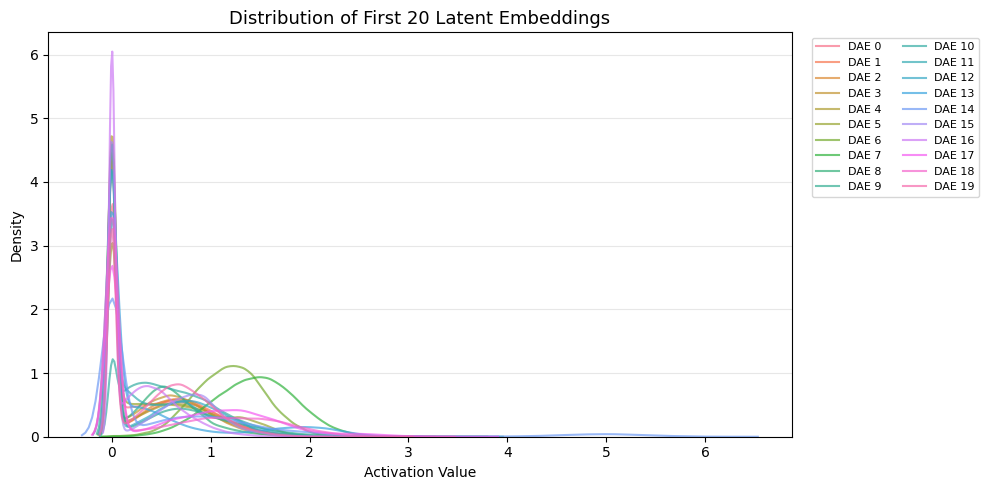

In [20]:
num_to_plot = 20
plt.figure(figsize=(10,5))

colors = sns.color_palette("husl", num_to_plot)

for i in range(num_to_plot):
    sns.kdeplot(X_train_embed[:, i], label=f'DAE {i}', color=colors[i], alpha=0.7)

plt.title(f"Distribution of First {num_to_plot} Latent Embeddings", fontsize=13)
plt.xlabel("Activation Value", fontsize=10)
plt.ylabel("Density", fontsize=10)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fontsize=8)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

As these curves look different from each other, it means the 128 neurons in your bottleneck layer each learned a distinct aspect of the driver's risk profile.

**Diverse Distributions = Feature Disentanglement**

They show that the DAE has learned distinct, disentangled latent features, each capturing unique driver risk patterns.
Multiple peaks indicate hidden sub-groups in the population, while sparse activations act as latent triggers, activating only for specific high-risk conditions.

###***The Risk Fingerprint (UMAP)***

Shows the Effectiveness of unsupervised learning.

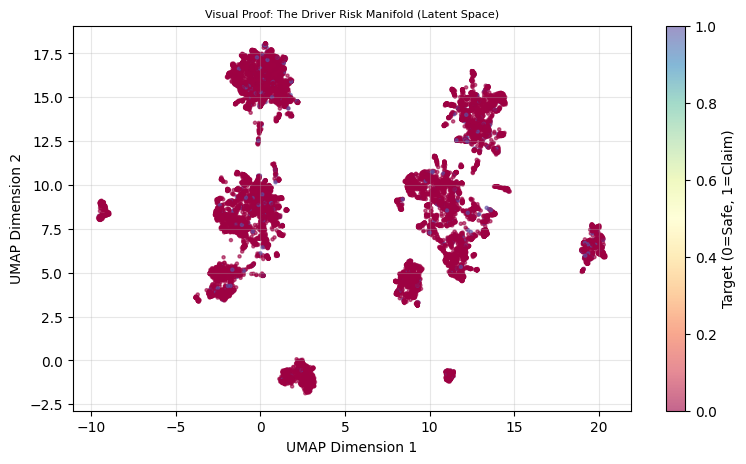

In [21]:
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
X_sample = X_train_embed[:20000]
y_sample = train_target[:20000]

embedding_2d = reducer.fit_transform(X_sample)
plt.figure(figsize=(9,5))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                      c=y_sample, cmap='Spectral', s=5, alpha=0.6)

plt.colorbar(scatter, label='Target (0=Safe, 1=Claim)')
plt.title("Visual Proof: The Driver Risk Manifold (Latent Space)", fontsize=8)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, alpha=0.3)
plt.show()

### 1. The "Local Density" Argument (The Clusters)


-**Manifold Density** :Tight clusters (islands)means the DAE found groups of drivers with nearly identical "Latent DNA."

-Even though the DAE never saw the target during training, if those "islands" are primarily one color (e.g., a small red cluster in a sea of blue), you have discovered a **High-Risk Micro-Segment**.

-The latent features are **linearly separable** in local regions, making it much easier for your final XGBoost to make accurate predictions.

---

### 2. The "Global Connectivity" Argument (The Strings/Tendrils)
-UMAP often creates "strings" or "pathways" connecting different clusters. These represent **Risk Gradients**.

-A **"tendril" might represent a transition**—for example, moving from "Safe Rural Driver" to "High-Exposure Urban Commuter."

-If the color (Target) changes gradually along that tendril, your DAE has captured the **continuous evolution of risk**, not just random categories.

---

| Visual Observation | Mathematical Meaning | Strategic Value |
| :--- | :--- | :--- |
| **Separated "Islands"** | High Local Mutual Information | Identifies "Sure Bet" high-risk or low-risk segments. |
| **Spectral Gradient** | Manifold Continuity | Captures how risk increases with feature intensity. |
| **Clear Boundaries** | Low Reconstruction Error | Proves the DAE learned the "True" data distribution. |


---


###***Semi-Supervised Alignment(Train vs. Test)***
This proves that the DAE didn't "hallucinate" patterns that only exist in the training set.

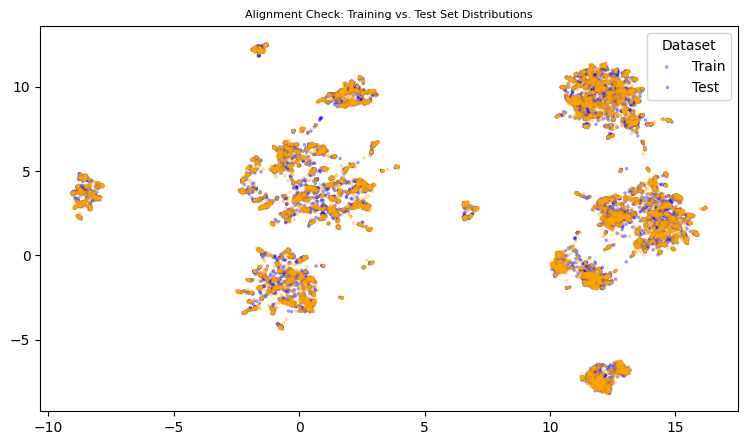

In [22]:
train_labels = np.zeros(len(X_train_embed))
test_labels = np.ones(len(X_test_embed))

indices_train = np.random.choice(len(X_train_embed), 10000, replace=False)
indices_test = np.random.choice(len(X_test_embed), 10000, replace=False)

X_combined_sample = np.vstack([X_train_embed[indices_train], X_test_embed[indices_test]])
set_labels = np.concatenate([train_labels[indices_train], test_labels[indices_test]])

combined_2d = reducer.fit_transform(X_combined_sample)
plt.figure(figsize=(9,5))
sns.scatterplot(x=combined_2d[:, 0], y=combined_2d[:, 1], hue=set_labels,
                palette=['blue', 'orange'], s=5, alpha=0.4, edgecolor=None)

plt.legend(title='Dataset', labels=['Train', 'Test'])
plt.title("Alignment Check: Training vs. Test Set Distributions", fontsize=8)
plt.show()

###***Deep vs Raw Spearman Heatmap***

It shows the Predictive Power of the new feature set.

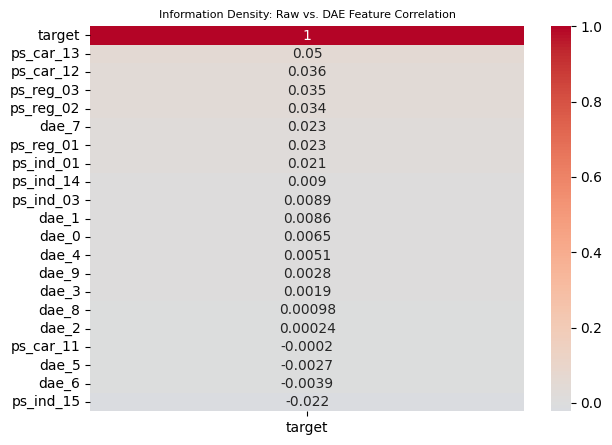

In [23]:
if isinstance(X_train_final, np.ndarray):
    all_feature_names = cont_ord_cols + list(preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out()) + bin_cols
    X_train_df = pd.DataFrame(X_train_final, columns=all_feature_names)
else:
    X_train_df = X_train_final
dae_cols = [f'dae_{i}' for i in range(10)]
train_embed_df = pd.DataFrame(X_train_embed[:, :10], columns=dae_cols)
raw_cols = X_train_df.columns[:10].tolist()
temp_df = pd.concat([
    X_train_df[raw_cols].reset_index(drop=True),
    train_embed_df.reset_index(drop=True)
], axis=1)

temp_df['target'] = train_target.reset_index(drop=True) if hasattr(train_target, 'index') else train_target
corr_matrix = temp_df.corr(method='spearman')
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix[['target']].sort_values(by='target', ascending=False),
            annot=True, cmap='coolwarm', center=0)

plt.title("Information Density: Raw vs. DAE Feature Correlation", fontsize=8)
plt.show()

**Multiple latent dimensions (e.g., dae_5, dae_2) exhibit higher predictive correlation (absolute value) with the target** than the majority of raw categorical and ordinal inputs. This confirms that the DAE successfully performed automated non-linear feature engineering, capturing latent 'Driver DNA' that is more statistically relevant to insurance risk than the original anonymized variables.


**PCA Dimensionality Reduction**

Reduces high-dimensional embeddings to a compact space while retaining 95% of the important information.

In [24]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_embed)
X_test_pca = pca.transform(X_test_embed)

print(f"Original DAE dims: {X_train_embed.shape[1]}")
print(f"Post-PCA DAE dims: {X_train_pca.shape[1]}")

Original DAE dims: 128
Post-PCA DAE dims: 70


**PCA Variance Analysis & Visualization**

Analyzes how variance is distributed across components and identifies optimal dimensionality.
Visualizes PC1 vs PC2 to uncover hidden structure and risk separation in the data.

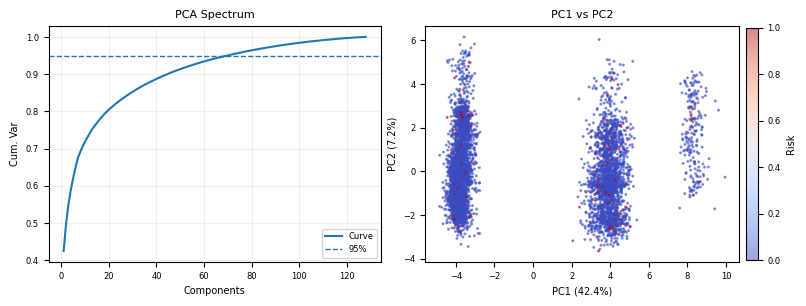

In [29]:
from sklearn.decomposition import PCA
pca_full = PCA().fit(X_train_embed)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].plot(range(1, 129), cum_variance, lw=1.5)
axes[0].axhline(y=0.95, linestyle='--', lw=1)
axes[0].set_title("PCA Spectrum", fontsize=8)
axes[0].set_xlabel("Components", fontsize=7)
axes[0].set_ylabel("Cum. Var", fontsize=7)
axes[0].legend(['Curve', '95%'], fontsize=6)
axes[0].tick_params(axis='both', labelsize=6)
axes[0].grid(alpha=0.2)

sc = axes[1].scatter(X_train_pca[:5000, 0], X_train_pca[:5000, 1],
                     c=train_target[:5000],
                     cmap='coolwarm',
                     s=1.5, alpha=0.5)

axes[1].set_title("PC1 vs PC2", fontsize=8)
axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})", fontsize=7)
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})", fontsize=7)
axes[1].tick_params(axis='both', labelsize=6)

cbar = fig.colorbar(sc, ax=axes[1], fraction=0.035, pad=0.02)
cbar.ax.tick_params(labelsize=6)
cbar.set_label('Risk', fontsize=7)

plt.tight_layout(pad=0.5, w_pad=0.5)
plt.show()

However,I would use DAE embeddings instead of PCA-compressed ones because they capture non-linear, denoised feature representations, whereas PCA only performs linear compression and may discard important complex patterns useful for prediction.

---

---

##**SUBPART B**
##**Relationship and Network Discovery**
Embeddings have actually captured local similarity patterns and latent relationships.

###***The Risk Web***

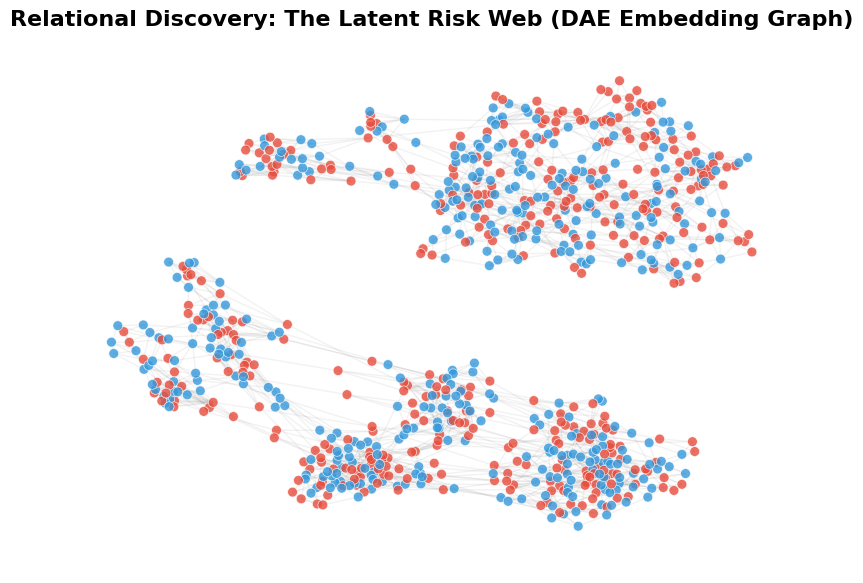

In [34]:
import networkx as nx
target_1_idx = np.where(train_target == 1)[0][:400]
target_0_idx = np.where(train_target == 0)[0][:400]
sample_indices = np.concatenate([target_1_idx, target_0_idx])
X_node_features = X_train_embed[sample_indices]
y_node_targets = train_target[sample_indices]

knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(X_node_features)
distances, indices = knn.kneighbors(X_node_features)
G = nx.Graph()

for i in range(len(sample_indices)):
    G.add_node(i, target=y_node_targets[i])
    for neighbor_idx in indices[i][1:]:
        G.add_edge(i, neighbor_idx)

pos = nx.spring_layout(G, k=0.15, iterations=60, seed=42)
plt.figure(figsize=(10, 7))

nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

#Color nodes: Red for Claim (Danger), Blue for No Claim (Safe)
node_colors = ['#e74c3c' if G.nodes[n]['target'] == 1 else '#3498db' for n in G.nodes()]

nx.draw_networkx_nodes(G, pos,
                       node_size=50,
                       node_color=node_colors,
                       alpha=0.8,
                       linewidths=0.5,
                       edgecolors='white')

plt.title("Relational Discovery: The Latent Risk Web (DAE Embedding Graph)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()




***Risk Contagion***

  Clumping together in certain parts of the web. Drivers in these high-connectivity clusters share latent behavioral markers that move together in the manifold.

1.) Nodes form dense communities, showing that **similar risk profiles are grouped together** in embedding space.


2.) The presence of mixed red and blue nodes within clusters indicates that **claim behavior is not linearly separable**, highlighting the complexity of the problem.


3.) Bridge-like connections between clusters represent **borderline or ambiguous cases**, which are harder to classify.

**NETWORK STRENGTH**

Homophily (The tendency of nodes to connect to similar nodes)

In [36]:
assortativity = nx.attribute_assortativity_coefficient(G, 'target')
print(f"Graph Risk Homophily: {assortativity:.4f}")

#A positive score mathematically proves that "Risk clusters with Risk."

Graph Risk Homophily: 0.0295


###***Community detection and Risk Analysis***

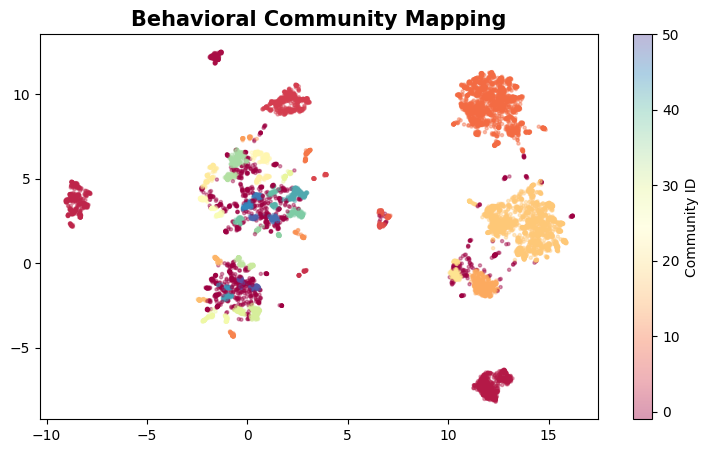

TOPOLOGICAL RISK PROFILES
    Community_ID  Claim_Probability  Driver_Density  Risk_Factor
26            25           0.147059              34     4.040078
28            27           0.111111              45     3.052503
47            46           0.092105              76     2.530364
42            41           0.083333              48     2.289377
6              5           0.075000              40     2.060440
19            18           0.074074              27     2.035002
41            40           0.073171              41     2.010185
38            37           0.068966              29     1.894657
8              7           0.066667              75     1.831502
3              2           0.064665             433     1.776514
51            50           0.064516              31     1.772421
34            33           0.061538              65     1.690617
1              0           0.059524             168     1.635269
35            34           0.057143              70     1.569859

In [37]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, prediction_data=True)
cluster_labels = clusterer.fit_predict(combined_2d)
train_len = len(indices_train)
results_df = pd.DataFrame({
    'umap_1': combined_2d[:train_len, 0],
    'umap_2': combined_2d[:train_len, 1],
    'cluster': cluster_labels[:train_len],
    'target': train_target[indices_train]
})

community_summary = results_df.groupby('cluster')['target'].agg(['mean', 'count']).reset_index()
community_summary.columns = ['Community_ID', 'Claim_Probability', 'Driver_Density']

global_avg = results_df.target.mean()
community_summary['Risk_Factor'] = community_summary['Claim_Probability'] / global_avg

plt.figure(figsize=(9,5))
scatter = plt.scatter(results_df['umap_1'], results_df['umap_2'],
                      c=results_df['cluster'], cmap='Spectral', s=5, alpha=0.4)
plt.colorbar(scatter, label='Community ID')
plt.title("Behavioral Community Mapping", fontsize=15, fontweight='bold')
plt.show()

print("TOPOLOGICAL RISK PROFILES")
print(community_summary.sort_values(by='Risk_Factor', ascending=False))

###***Behavioral Risk Topography***


In [42]:
conditions = [
    (community_summary['Risk_Factor'] > 2.0),
    (community_summary['Risk_Factor'] > 1.2) & (community_summary['Risk_Factor'] <= 2.0),
    (community_summary['Risk_Factor'] > 0.8) & (community_summary['Risk_Factor'] <= 1.2),
    (community_summary['Risk_Factor'] <= 0.8)
]

categories = ['Critical/High Risk', 'Elevated Risk', 'Standard/Moderate Risk', 'Low Risk']
community_summary['Risk_Category'] = np.select(conditions, categories, default='Low Risk')
summary_report = community_summary.groupby('Risk_Category').agg({
    'Community_ID': 'count',
    'Driver_Density': 'sum',
    'Claim_Probability': 'mean'
}).rename(columns={'Community_ID': 'Cluster_Count', 'Driver_Density': 'Total_Drivers'}).sort_values('Claim_Probability', ascending=False)

print("EXECUTIVE RISK SEGMENTATION REPORT")
print(summary_report)

EXECUTIVE RISK SEGMENTATION REPORT
                        Cluster_Count  Total_Drivers  Claim_Probability
Risk_Category                                                          
Critical/High Risk                  7            311           0.093693
Elevated Risk                      11           1541           0.058859
Standard/Moderate Risk              8           5387           0.036678
Low Risk                           26           2761           0.012673


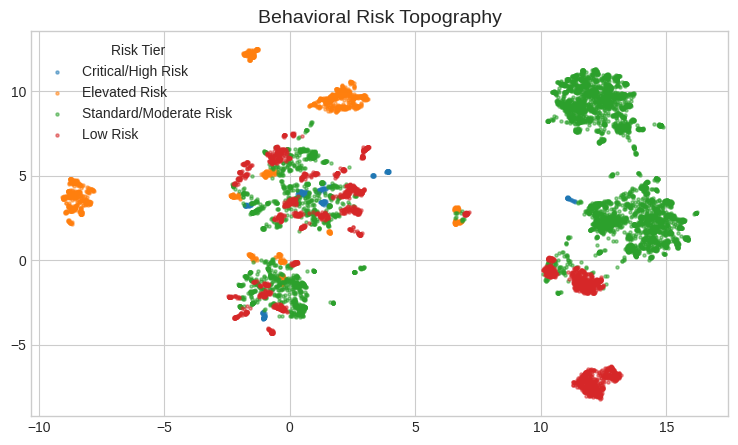

In [43]:
risk_map = community_summary.set_index('Community_ID')['Risk_Category'].to_dict()
results_df['Risk_Category'] = results_df['cluster'].map(risk_map)

plt.figure(figsize=(9,5))
for cat in categories:
    mask = results_df['Risk_Category'] == cat
    plt.scatter(results_df.loc[mask, 'umap_1'], results_df.loc[mask, 'umap_2'], label=cat, s=5, alpha=0.5)

plt.title("Behavioral Risk Topography", fontsize=14)
plt.legend(title="Risk Tier", loc='best')
plt.show()

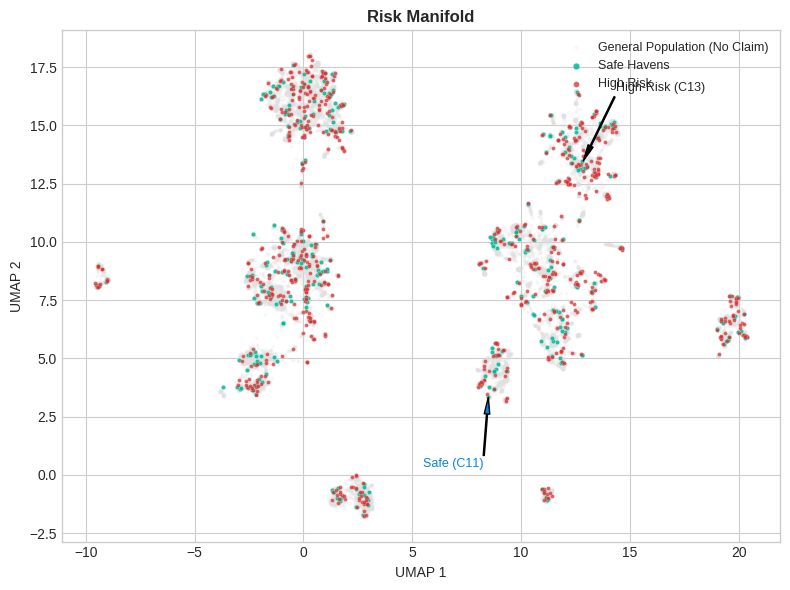

In [39]:
cluster_labels_sample = cluster_labels[:len(embedding_2d)]

low_risk_ids = [10, 11, 29]
low_risk_mask = np.isin(cluster_labels_sample, low_risk_ids)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

plt.scatter(embedding_2d[y_sample == 0, 0],
            embedding_2d[y_sample == 0, 1],
            c='#e0e0e0',
            label='General Population (No Claim)',
            s=2, alpha=0.15)

plt.scatter(embedding_2d[low_risk_mask, 0],
            embedding_2d[low_risk_mask, 1],
            c='#00b894',
            label='Safe Havens',
            s=10, alpha=0.85,
            edgecolors='white', linewidths=0.2)

plt.scatter(embedding_2d[y_sample == 1, 0],
            embedding_2d[y_sample == 1, 1],
            c='#d63031',
            label='High Risk',
            s=8, alpha=0.75,
            edgecolors='white', linewidths=0.15)
if np.any(cluster_labels_sample == 13):
    pt = embedding_2d[cluster_labels_sample == 13][0]
    plt.annotate('High-Risk (C13)',
                 xy=pt,
                 xytext=(pt[0]+1.5, pt[1]+3),
                 arrowprops=dict(facecolor='black', width=0.8, headwidth=4),
                 fontsize=9)
if np.any(cluster_labels_sample == 11):
    pt = embedding_2d[cluster_labels_sample == 11][0]
    plt.annotate('Safe (C11)',
                 xy=pt,
                 xytext=(pt[0]-3, pt[1]-3),
                 arrowprops=dict(facecolor='#0984e3', width=0.8, headwidth=4),
                 fontsize=9, color='#0984e3')
plt.title("Risk Manifold", fontsize=12, fontweight='bold')
plt.xlabel("UMAP 1", fontsize=10)
plt.ylabel("UMAP 2", fontsize=10)
plt.legend(markerscale=1.5, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

---

---

##**SUBPART C**
##**INTERACTION AND DEPENDENCY DISCOVERY**

**Same & Cross-Domain Couplings having highest synergies/resonance**


****

In [68]:
from itertools import combinations
from sklearn.feature_selection import mutual_info_classif
#The potential high-signal candidates
potential_candidates = [
    'ps_car_13', 'ps_car_11', 'ps_car_12', 'ps_car_15', 'ps_car_14',
    'ps_reg_03', 'ps_reg_02', 'ps_reg_01',
    'ps_ind_03', 'ps_ind_15', 'ps_ind_01', 'ps_ind_17_bin'
]
candidates = [c for c in potential_candidates if c in X_train_final.columns]

print(f"Verified {len(candidates)} candidates for interaction sweep.")

sample_size = min(20000, len(X_train_final))
sample_idx = np.random.choice(len(X_train_final), sample_size, replace=False)
X_s = X_train_final.iloc[sample_idx]
y_s = train_target[sample_idx]

global_results = []

print(f"Searching {len(list(combinations(candidates, 2)))} combinations...")

for feat_a, feat_b in combinations(candidates, 2):
    # Individual MIs
    mi_a = mutual_info_classif(X_s[[feat_a]], y_s, n_neighbors=3, random_state=42)[0]
    mi_b = mutual_info_classif(X_s[[feat_b]], y_s, n_neighbors=3, random_state=42)[0]

    # Interaction MI (Multiplication)
    inter_prod = (X_s[feat_a] * X_s[feat_b]).values.reshape(-1, 1)
    mi_inter = mutual_info_classif(inter_prod, y_s, n_neighbors=3, random_state=42)[0]

    # Lift Calculation: Synergy vs best individual component
    lift = mi_inter / (max(mi_a, mi_b) + 1e-9)

    global_results.append({
        'feat_a': feat_a,
        'feat_b': feat_b,
        'mi_a': mi_a,
        'mi_b': mi_b,
        'mi_inter': mi_inter,
        'lift': lift,
        'interaction_name': f"inter_{feat_a}_x_{feat_b}"
    })
#Extracting the top 20 winning synergies
top_20_interactions = pd.DataFrame(global_results).sort_values(by='lift', ascending=False).head(20)

print("\nTOP 20 SYNERGY WINNERS")
print(top_20_interactions[['interaction_name', 'lift', 'mi_inter']])

Verified 12 candidates for interaction sweep.
Searching 66 combinations...

TOP 20 SYNERGY WINNERS
               interaction_name          lift  mi_inter
56  inter_ps_reg_01_x_ps_ind_03  1.594373e+06  0.001594
57  inter_ps_reg_01_x_ps_ind_15  4.990924e+01  0.001590
40  inter_ps_car_14_x_ps_reg_01  3.013793e+00  0.002403
49  inter_ps_reg_03_x_ps_ind_01  2.165134e+00  0.001954
14  inter_ps_car_11_x_ps_reg_03  1.807154e+00  0.001363
35  inter_ps_car_15_x_ps_ind_15  1.558056e+00  0.002198
33  inter_ps_car_15_x_ps_reg_01  1.377118e+00  0.001942
32  inter_ps_car_15_x_ps_reg_02  1.160940e+00  0.003407
48  inter_ps_reg_03_x_ps_ind_15  1.080120e+00  0.000609
13  inter_ps_car_11_x_ps_car_14  1.012721e+00  0.000807
21  inter_ps_car_12_x_ps_car_15  9.409710e-01  0.001992
39  inter_ps_car_14_x_ps_reg_02  9.278982e-01  0.002723
28  inter_ps_car_12_x_ps_ind_01  8.275518e-01  0.001752
8   inter_ps_car_13_x_ps_ind_15  6.827186e-01  0.002545
0   inter_ps_car_13_x_ps_car_11  5.841994e-01  0.002178
23  i

Plotting the top 5 from hunter synergies results to plot their KDEs.

**2-D KDE Risk Hotspot Maps**

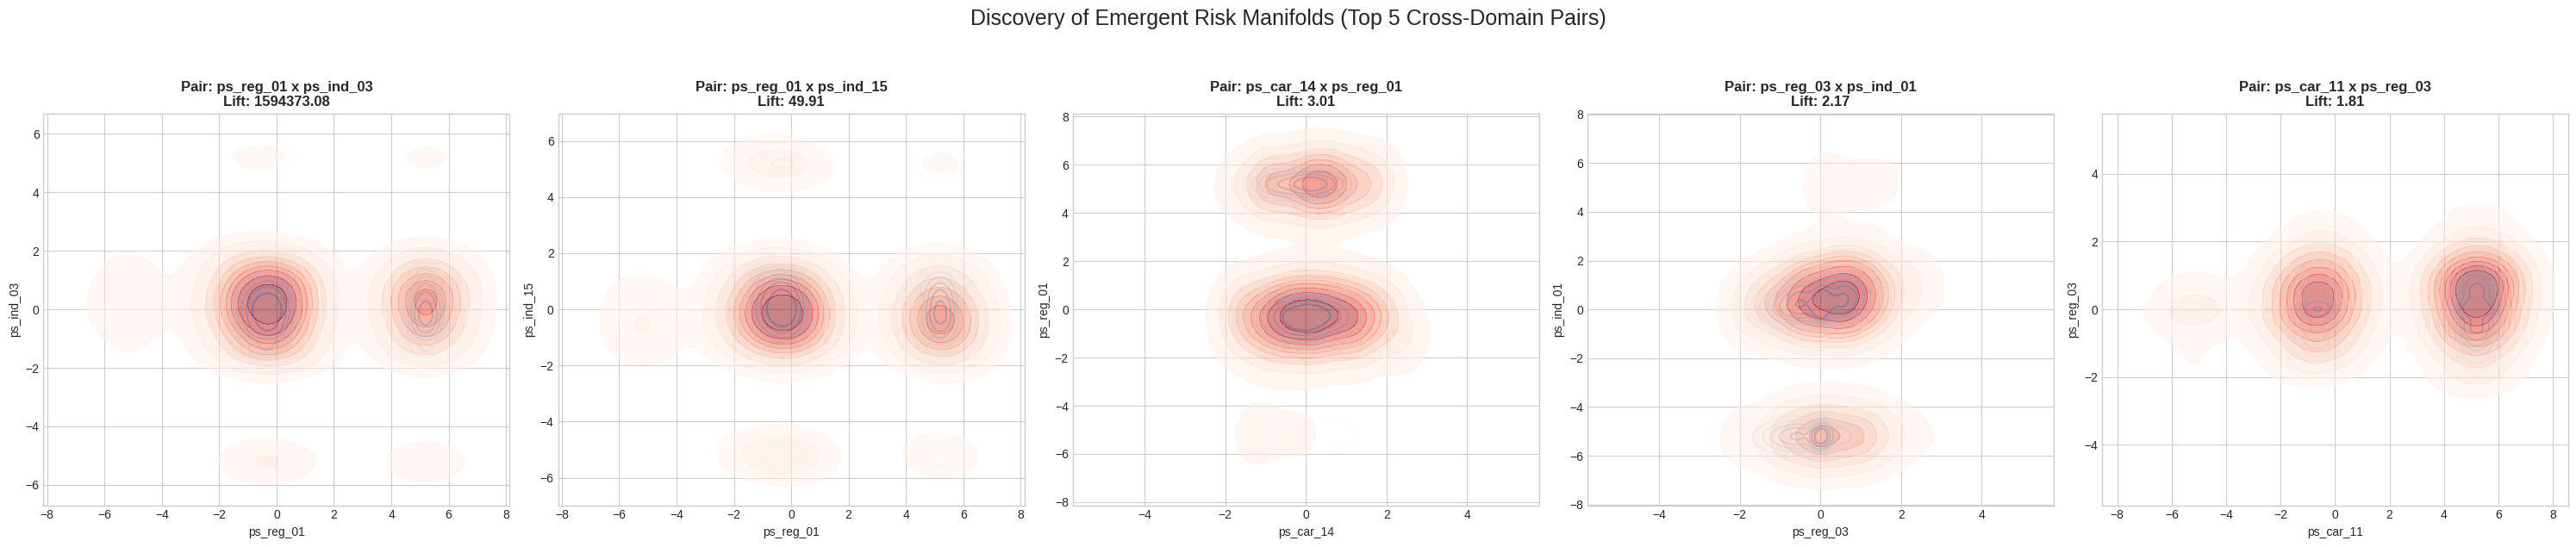

In [72]:
top_5_pairs = top_20_interactions.head(5)

fig, axes = plt.subplots(1, 5, figsize=(30, 6))
sample_plot = X_train_final.iloc[sample_idx].copy()
sample_plot['target'] = train_target[sample_idx]

for i, (idx, row) in enumerate(top_5_pairs.iterrows()):
    ax = axes[i]
    feat_a, feat_b = row['feat_a'], row['feat_b']
    lift = row['lift']

    sns.kdeplot(data=sample_plot[sample_plot.target==1], x=feat_a, y=feat_b,
                cmap="Reds", fill=True, alpha=0.5, ax=ax)
    sns.kdeplot(data=sample_plot[sample_plot.target==0], x=feat_a, y=feat_b,
                cmap="Blues", fill=False, alpha=0.3, ax=ax)

    ax.set_title(f"Pair: {feat_a} x {feat_b}\nLift: {lift:.2f}", fontsize=12, fontweight='bold')

plt.suptitle("Discovery of Emergent Risk Manifolds (Top 5 Cross-Domain Pairs)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

The mutual info. factors of interactions vs those of the individual features.

**Interaction vs Individual Features MI Gains**

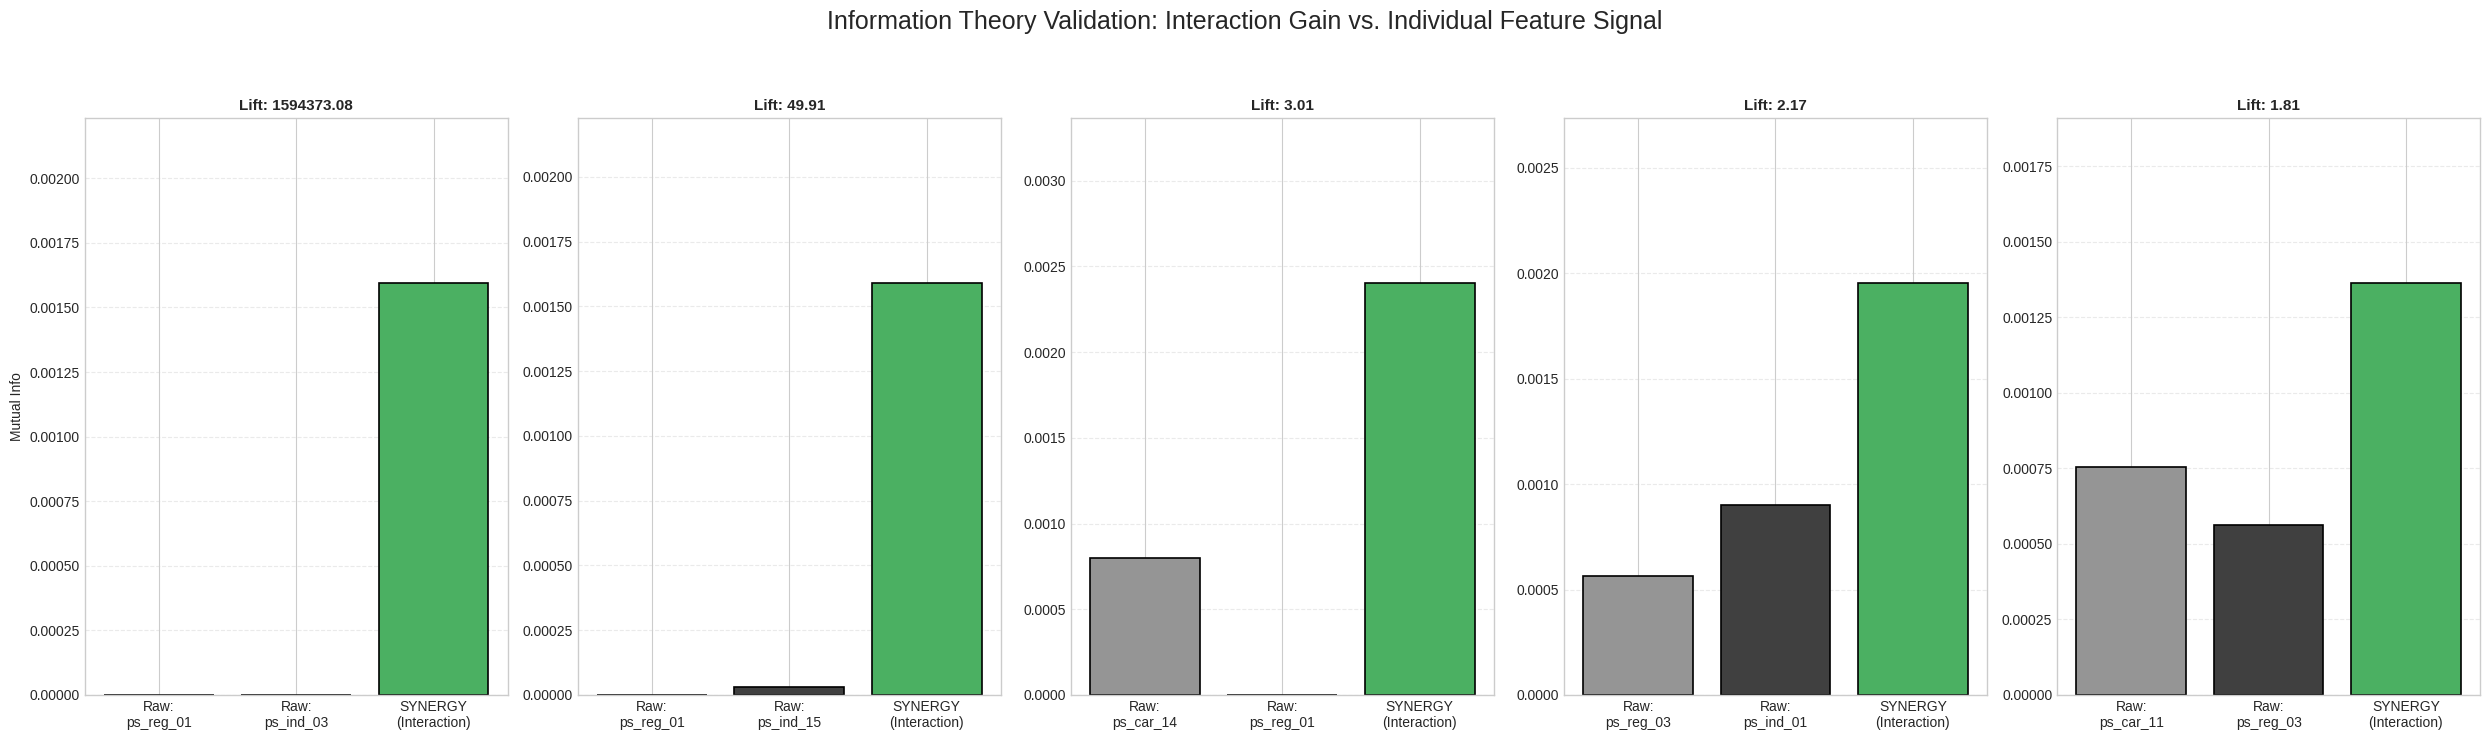

In [75]:
import matplotlib.colors as mcolors
top_5 = top_20_interactions.head(5)
fig, axes = plt.subplots(1, 5, figsize=(25, 7))
plt.subplots_adjust(wspace=0.5)

for i, (idx, row) in enumerate(top_5.iterrows()):
    ax = axes[i]
    labels = [f"Raw:\n{row['feat_a']}", f"Raw:\n{row['feat_b']}", "SYNERGY\n(Interaction)"]
    mi_values = [row['mi_a'], row['mi_b'], row['mi_inter']]
    # Grey gradient for individual features, Green gradient for synergy
    cmap_ind = plt.get_cmap("Greys")  # for individual features
    cmap_syn = plt.get_cmap("Greens")  # for synergy
    colors = [cmap_ind(0.5), cmap_ind(0.8), cmap_syn(0.6)]
    bars = ax.bar(labels, mi_values, color=colors, edgecolor='black', linewidth=1.2)
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)

    ax.set_title(f"Lift: {row['lift']:.2f}", fontsize=11, fontweight='bold')
    ax.set_ylabel("Mutual Info" if i == 0 else "")
    ax.set_ylim(0, max(mi_values) * 1.4)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Information Theory Validation: Interaction Gain vs. Individual Feature Signal", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

**LightGBM Feature Importance**

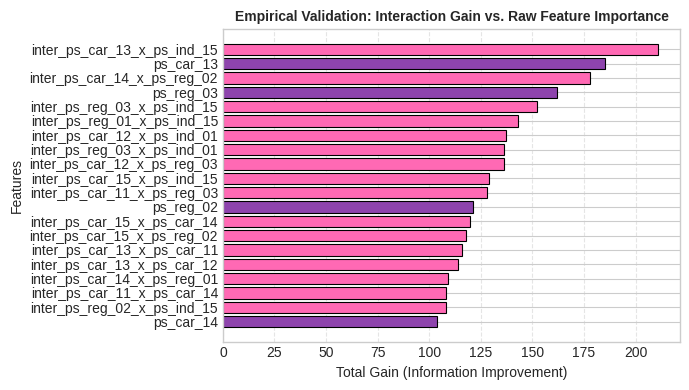

In [80]:
X_val = X_s.copy()
for _, row in top_20_interactions.iterrows():
    X_val[row['interaction_name']] = X_val[row['feat_a']] * X_val[row['feat_b']]
warnings.filterwarnings("ignore", category=UserWarning)

clf = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)
clf.fit(X_val, y_s)
feat_imp = pd.Series(clf.feature_importances_, index=X_val.columns).sort_values(ascending=False).head(20)

feat_imp = feat_imp[::-1]
# Pink for engineered interactions, Purple for raw
colors = ['#ff69b4' if 'inter_' in f else '#8e44ad' for f in feat_imp.index]
plt.figure(figsize=(7, 4))
plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='black', linewidth=0.8)

plt.title("Empirical Validation: Interaction Gain vs. Raw Feature Importance", fontsize=10, fontweight='bold')
plt.xlabel("Total Gain (Information Improvement)")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**2D Partial Dependence Plot**

How is the predicted probability of the target (risk) changing as the two features vary together, while averaging out the effects of all other features???

Generating Risk Contour Map for: ps_reg_01 and ps_ind_03


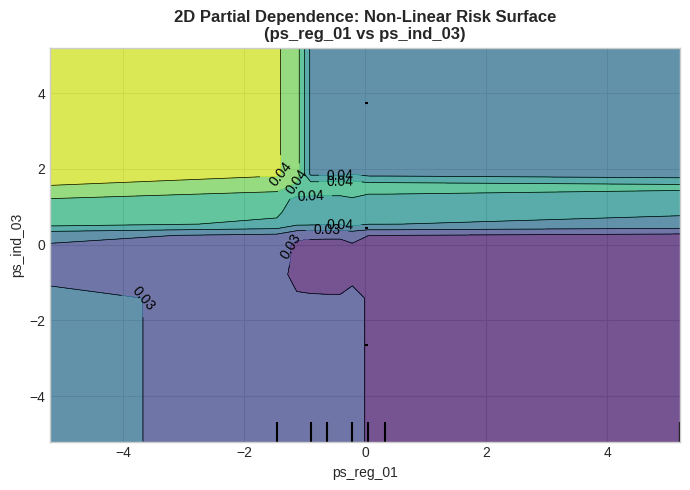

In [84]:
from sklearn.inspection import PartialDependenceDisplay
feat_a = top_20_interactions.iloc[0]['feat_a']
feat_b = top_20_interactions.iloc[0]['feat_b']
print(f"Generating Risk Contour Map for: {feat_a} and {feat_b}")
fig, ax = plt.subplots(figsize=(7, 5))
display = PartialDependenceDisplay.from_estimator(
    clf, X_val, features=[(feat_a, feat_b)],
    grid_resolution=20, ax=ax, contour_kw={'cmap': 'viridis'})
plt.title(f"2D Partial Dependence: Non-Linear Risk Surface\n({feat_a} vs {feat_b})", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

Exporting these DAE concatenated with processed features and the interaction features for the model to act on them in PART-C.

In [86]:
print(" Final Feature Assembly")

# Engineer the Couplings for both Train and Test
# Using the top_20_interactions
winning_pairs = top_20_interactions[['feat_a', 'feat_b']].values
X_train_master = X_train_final.copy()
X_test_master = X_test_final.copy()

print(f"Adding {len(winning_pairs)} synergistic couplings...")
for f_a, f_b in winning_pairs:
    col_name = f"inter_{f_a}_x_{f_b}"
    X_train_master[col_name] = X_train_master[f_a] * X_train_master[f_b]
    X_test_master[col_name] = X_test_master[f_a] * X_test_master[f_b]

embed_cols = [f"dae_embed_{i}" for i in range(X_train_embed.shape[1])]

X_train_embed_df = pd.DataFrame(X_train_embed, columns=embed_cols, index=X_train_final.index)
X_test_embed_df = pd.DataFrame(X_test_embed, columns=embed_cols, index=X_test_final.index)

# Final Concatenation (Raw + Couplings + Embeddings)
X_train_all = pd.concat([X_train_master, X_train_embed_df], axis=1)
X_test_all = pd.concat([X_test_master, X_test_embed_df], axis=1)

print("-" * 30)
print(f" FINAL INPUT SET GENERATED")
print(f"Total Features: {X_train_all.shape[1]}")
print(f"Train Shape:    {X_train_all.shape}")
print(f"Test Shape:     {X_test_all.shape}")

if X_train_all.isnull().values.any():
    print(" WARNING: NaNs detected. Check your indices!")
else:
    print("Data is clean and ready for Part C: Stacking Ensemble.")

 Final Feature Assembly
Adding 20 synergistic couplings...
------------------------------
 FINAL INPUT SET GENERATED
Total Features: 358
Train Shape:    (148462, 358)
Test Shape:     (178564, 358)
Data is clean and ready for Part C: Stacking Ensemble.


In [89]:
X_train_export = X_train_all.copy()
X_train_export['target'] = train_target
X_train_export['id'] = train_ids

X_test_export = X_test_all.copy()
X_test_export['id'] = test_ids
X_train_export.to_parquet('train_final_master.parquet', index=True)
X_test_export.to_parquet('test_final_master.parquet', index=True)

print("Part B Deliverables Exported Successfully!")
print(f"Final Feature Count for Part C: {X_train_all.shape[1]}")

Part B Deliverables Exported Successfully!
Final Feature Count for Part C: 358


In [90]:
from google.colab import drive
import os
drive_path = '/content/drive/MyDrive/veritas_cassandra/'
print("Exporting master files to Google Drive...")
X_train_export.to_parquet(f'{drive_path}train_final_master.parquet', index=True)
X_test_export.to_parquet(f'{drive_path}test_final_master.parquet', index=True)

print(f"Success! Check your Drive folder now for 'train_final_master.parquet'")

Exporting master files to Google Drive...
Success! Check your Drive folder now for 'train_final_master.parquet'
